# Analysis of wavefront sensor data from ALS 5.3.1

Date: Created May 2026 

Author: Wei "Francis" He (francisho@lbl.gov / whorwhey@gmail.com)

Based on earlier versions by Dr. Antoine Islegen-Wojdyla and myself. 

___

## Overview

This is a updated template notebook to run `wfs_live` script to reconstruct the beam wavefront. 


# SETUP 

In [1]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

from PIL import Image

import wfs_live as wfl


In [2]:
# Load TIFF Image
filename = "WFS210515-0002-025.tif"
im = Image.open(f'{filename}')
width, height = im.size

print(f"Loaded: {filename}")
print(f"Image dimensions: {width} × {height} pixels")

# Visualize full image
plt.figure(figsize=(8, 5))
plt.imshow(np.array(im), cmap='hot', interpolation='nearest', vmax=3000)
plt.title(f'Full TIFF Image: {filename}', fontsize=13)
plt.xlabel('X pixels', fontsize=11)
plt.ylabel('Y pixels', fontsize=11)
plt.colorbar(label='Intensity [counts]')
plt.tight_layout()
plt.show()

# Convert to numpy array for the rest of the analysis
im_arr = np.array(im, dtype=float)


FileNotFoundError: [Errno 2] No such file or directory: 'WFS210515-0002-025.tif'

In [3]:
# Physical Parameters (Experimental Setup)

camera_pixel_m = 3.45e-6      # Camera pixel size [m]
magnification = 2.85          # Objective magnification (Boli optics)
dx_m = camera_pixel_m / magnification  # Effective pixel size [m]

energy_eV = 607               # Photon energy [eV]
wavelength_m = wfl.energy_eV_to_wavelength_m(energy_eV)

# Grating
grating_pitch_m = 22e-6       # Shearing grating pitch [m]

# Geometry
z_gd_m = 0.4                  # Grating-to-detector distance [m]

# ROI: row band over the beam (fringes along x, beam centered ~y=1100)
y_roi = slice(1090, 1190)
axis  = 0                     # average over rows → profile along columns

print(f"λ = {wavelength_m*1e9:.3f} nm   dx = {dx_m*1e6:.2f} µm")
print(f"p = {grating_pitch_m*1e6:.0f} µm   z_gd = {z_gd_m*1e3:.0f} mm")


λ = 2.043 nm   dx = 1.21 µm
p = 22 µm   z_gd = 400 mm


# RECON


[good]  λ=2.04nm  k_peak=35.2 cyc/mm  k_amp=51023  f_pred=-1.77m  RMS_W=10.3nm  RMS_resid=0.006nm


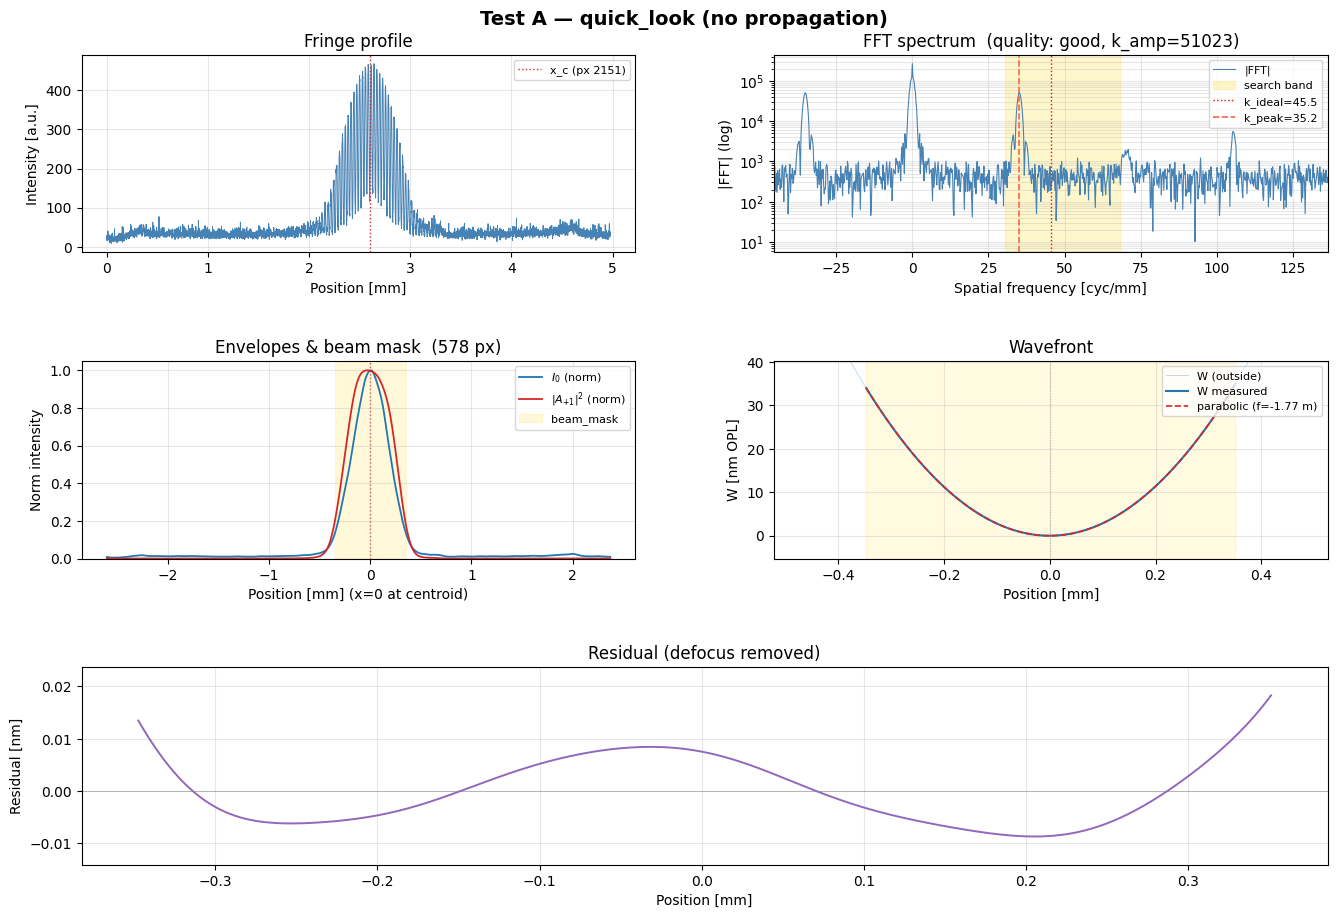

In [4]:
# Test A: quick_look (no propagation)
r_quick = wfl.quick_look(
    im_arr, dx_m, grating_pitch_m, wavelength_m, z_gd_m,
    y_roi=y_roi, axis=axis,
    title='Test A — quick_look (no propagation)',
)

[good]  λ=2.04nm  k_peak=35.2 cyc/mm  k_amp=51023  f_pred=-1.77m  RMS_W=10.3nm  RMS_resid=0.006nm  z_focus=-1.79m  RMS@focus=0.094nm


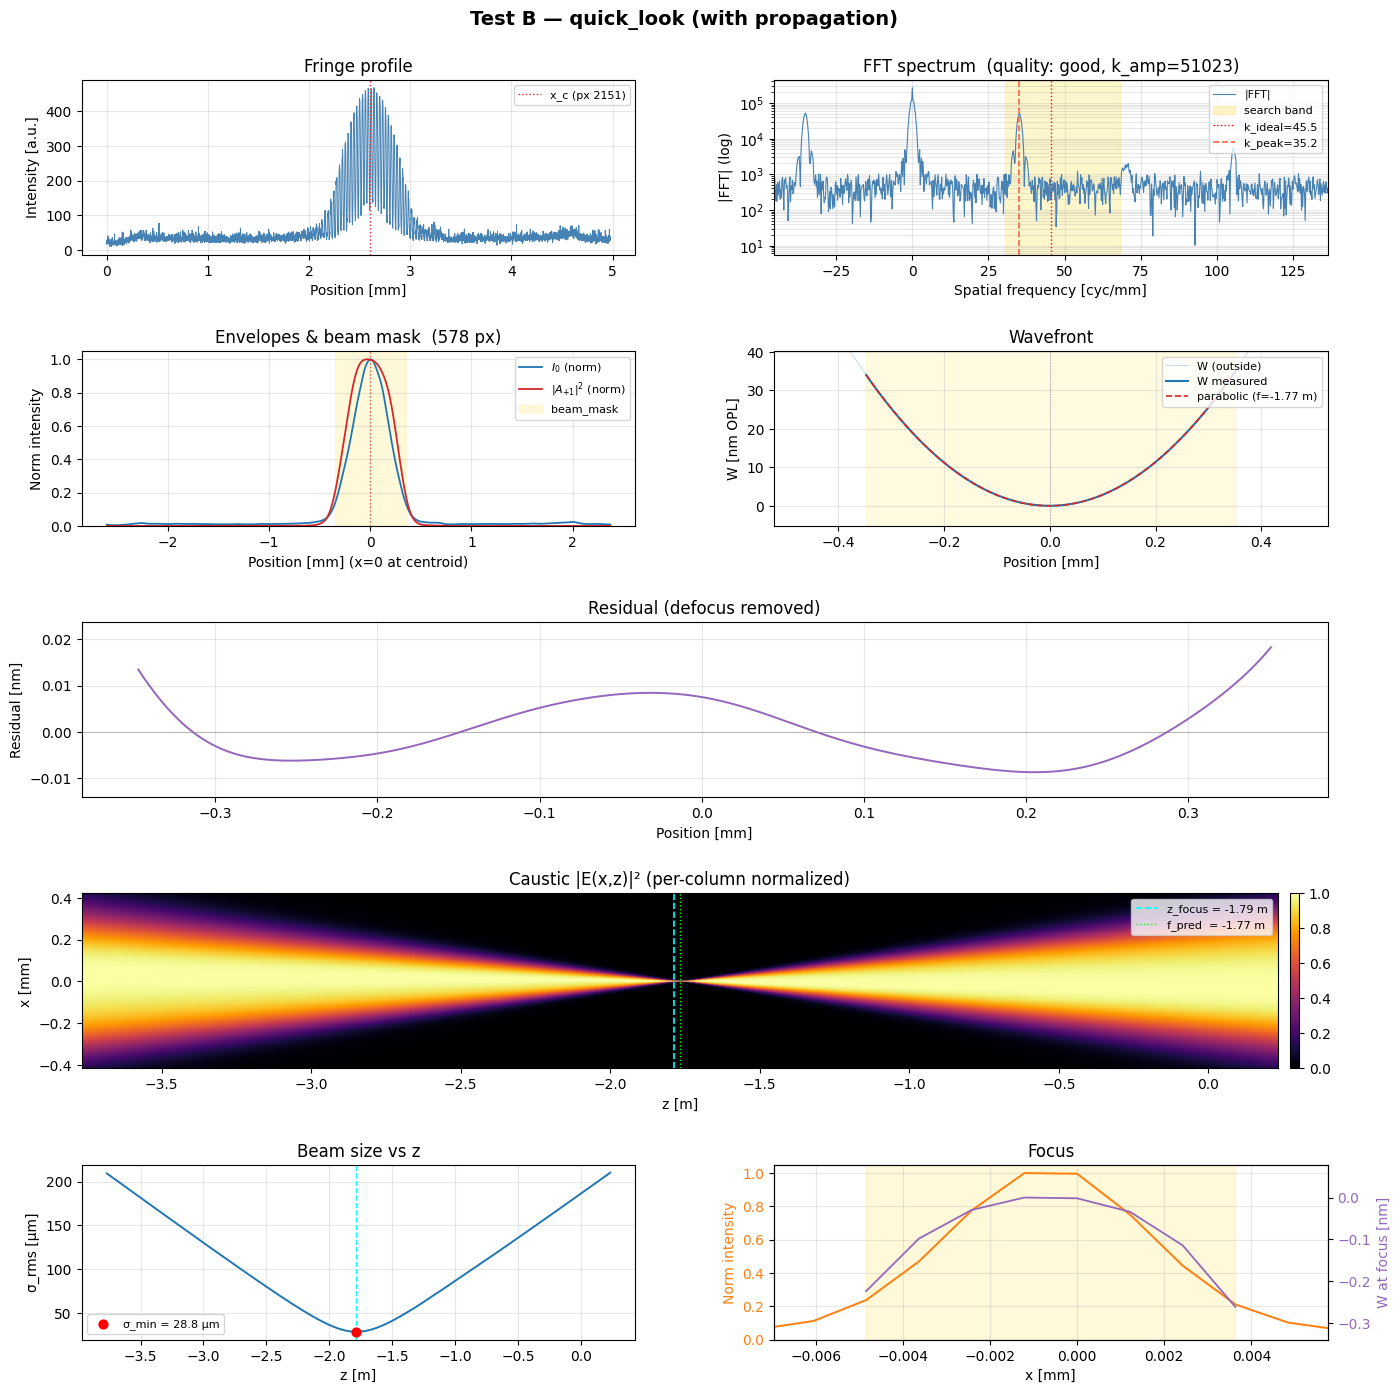

In [5]:
# Test B: quick_look with propagation
r_quick_prop = wfl.quick_look(
    im_arr, dx_m, grating_pitch_m, wavelength_m, z_gd_m,
    y_roi=y_roi, axis=axis,
    propagate=True,
    title='Test B — quick_look (with propagation)',
)

[good]  λ=2.04nm  k_peak=35.2 cyc/mm  k_amp=51023  f_pred=-1.77m  RMS_W=10.3nm  RMS_resid=0.006nm  z_focus=-1.79m  RMS@focus=0.094nm


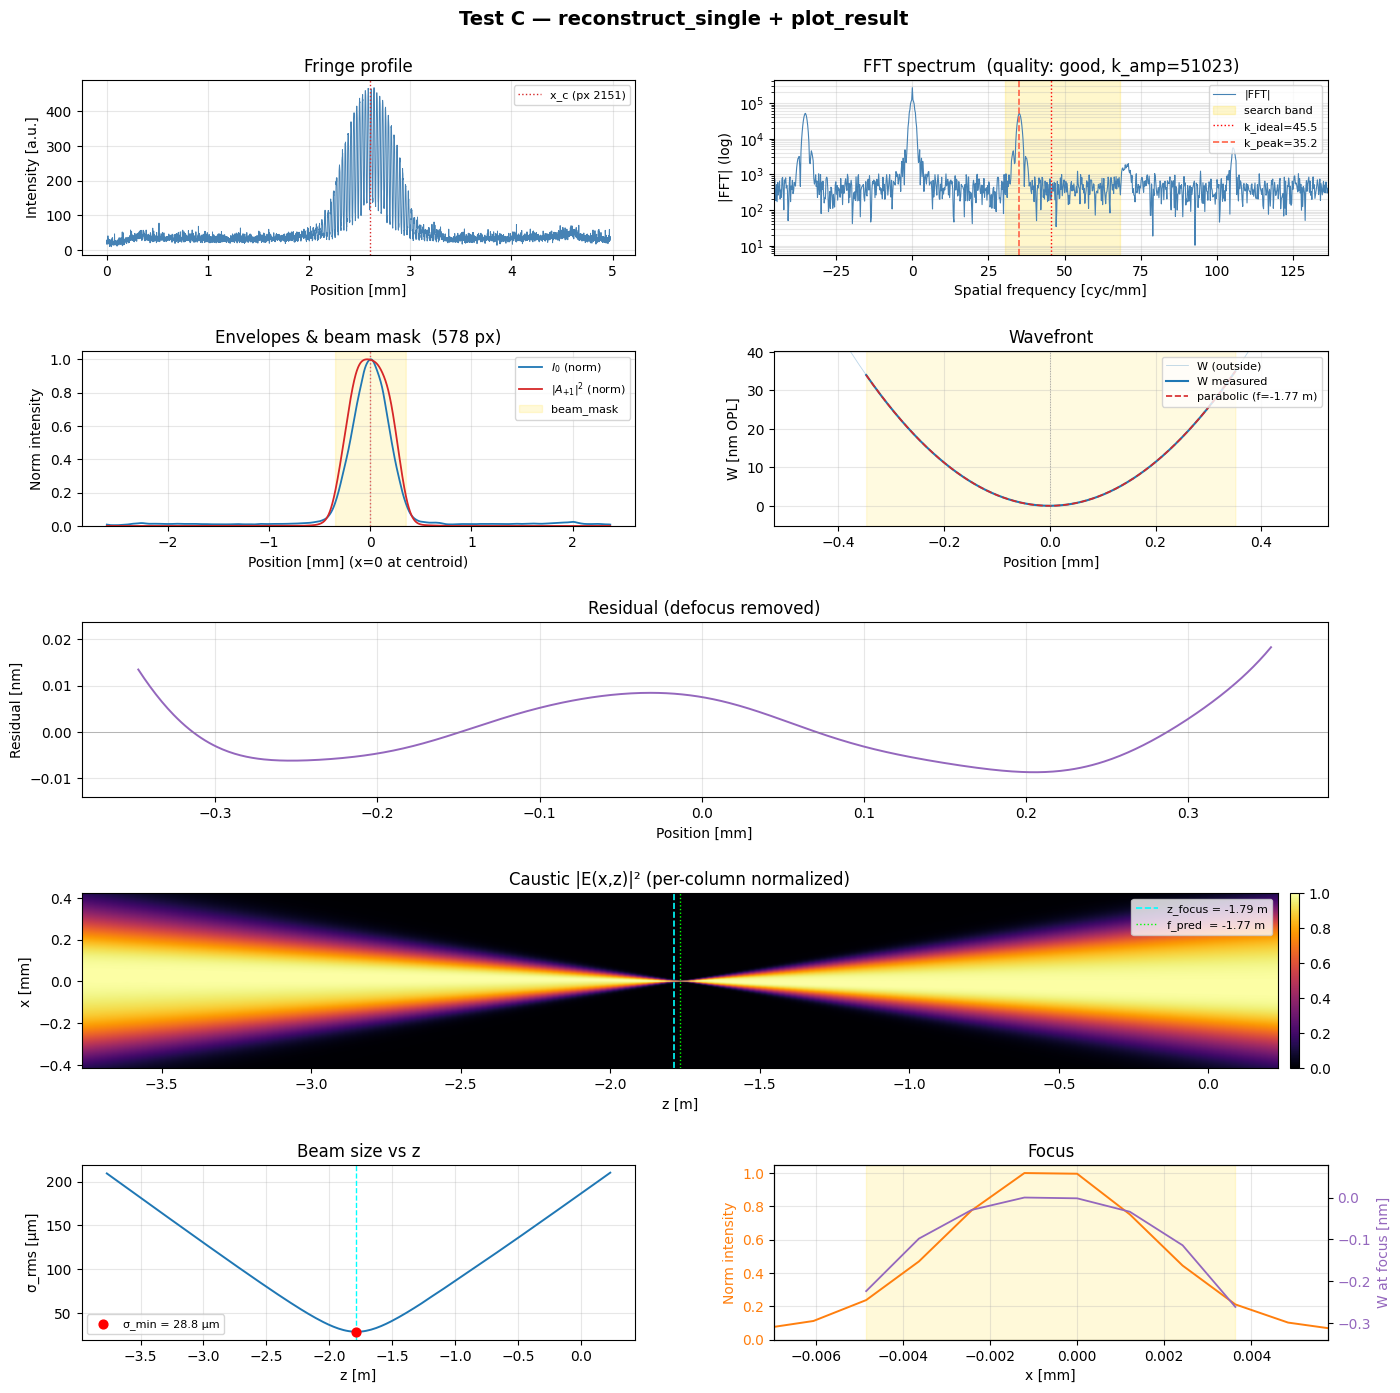


─── Self-consistency check (B vs C) ───
f_pred     B=-1.7677  C=-1.7677  m
z_focus    B=-1.7877  C=-1.7877  m
RMS@focus  B=0.0938  C=0.0938  nm


In [6]:
# Test C: reconstruct_single + plot_result separately
# Shows the manual two-step workflow that quick_look wraps
r_manual = wfl.reconstruct_single(
    im_arr, dx_m, grating_pitch_m, wavelength_m, z_gd_m,
    y_roi=y_roi, axis=axis,
    propagate=True,
    verbose=True,
)
wfl.plot_result(r_manual, title='Test C — reconstruct_single + plot_result')

# Confirm B and C give identical numbers
print("\n─── Self-consistency check (B vs C) ───")
print(f"f_pred     B={r_quick_prop['f_pred']:+.4f}  C={r_manual['f_pred']:+.4f}  m")
print(f"z_focus    B={r_quick_prop['z_focus']:+.4f}  C={r_manual['z_focus']:+.4f}  m")
print(f"RMS@focus  B={r_quick_prop['rms_at_focus_nm']:.4f}  C={r_manual['rms_at_focus_nm']:.4f}  nm")

## Currently Broken: Access Data from the Server

__Note:__ We tried read data from db with `tiled.__version__='0.2.9'`, but it failed; had to reinstall a 0.2.1 version to make it work. 

In [ ]:
# --- Server connection ---
api_key_path = "/Users/francisho/Documents/TILED_SINGLE_USER_API_KEY.txt"   # Change this path to where your API key is stored 

with open(api_key_path, "r") as f:
    api_key = f.read().strip()

if not api_key:
    raise ValueError("API key file is empty or not found.")

tiled_client = from_uri("http://131.243.80.226:8000", api_key=api_key)

__Important scans files:__

`Uid = '88dd6a7f-0338-446f-8185-fa9e004add04'`: A grid scan for `RE(grid_scan([basler_5472], mono_energy, 7000, 10000, 7, Obender, -2000, -0000, 11, snake_axes=False, md=md))`


In [ ]:
# --- Dataset ---
DATASET_ID = '88dd6a7f-0338-446f-8185-fa9e004add04'
db = tiled_client[DATASET_ID]

# Metadata

wfs_chip_pos_mm = db['baseline']['bcs_linear_motor'].read()
exp_time_s = db.metadata['start']['exposure time [s]']
pixel_size_um = db.metadata['start']['pixel size [um]']
binning = db.metadata['start']['binning']
effective_pixel_size_um = db.metadata['start']['effective pixel size [um]']
camera_model = db.metadata['start']['camera model']
objective_model = db.metadata['start']['objective model']

print(f"Camera:          {camera_model}")
print(f"Objective:       {objective_model}")
print(f"Pixel size:      {pixel_size_um} µm  (binning: {binning}×)")
print(f"Effective pixel: {effective_pixel_size_um} µm")
print(f"Exposure time:   {exp_time_s} s")
print(f"WFS chip position (mm): {wfs_chip_pos_mm}")


In [ ]:
# Arrays (slow, ~20 seconds to load) 
images    = db['primary']['basler_5472_image'].read()
energy_eV = db['primary']['mono_energy_energy_eV'].read()
bender_um = db['primary']['bender_um'].read()

print(f"Images shape: {images.shape}  (n_frames × height × width)")
print(f"Energy range: {energy_eV.min():.1f} – {energy_eV.max():.1f} eV")
print(f"       shape: {energy_eV.shape}")
print(f"Bender range: {bender_um.min():.1f} – {bender_um.max():.1f} µm")
print(f"       shape: {bender_um.shape}")

In [ ]:
# Physical Parameters (Experimental Setup)

camera_pixel_m = 3.45e-6      # Camera pixel size [m]
magnification = 2.85          # Objective magnification (Boli optics)
dx_m = camera_pixel_m / magnification  # Effective pixel size [m]

energy_eV = 607               # Photon energy [eV]
wavelength_m = 1.23984e-6 / energy_eV

# Grating
grating_pitch_m = 22e-6      # Shearing grating pitch [m]

# NOTES
